# 04 – MLP bằng PyTorch 
**Người Thực hiện: Nguyễn Thị Ngọc Trúc**

Kaggle *House Prices*. Notebook chạy từ thư mục `notebooks/`. Phần tuning (~15 phút) và EXP-00→05 (~40 phút) chạy bằng `src/train_mlp.py`; notebook này đọc lại kết quả đã lưu và chạy trực tiếp các bước nhẹ.

In [1]:
import sys; sys.path.insert(0,'../src')
import numpy as np, pandas as pd, torch
from IPython.display import Image, display
from sklearn.model_selection import train_test_split
from train_mlp import get_data, best_cfg, SEED, EXP_DIR
from preprocess import Preprocessor
from mlp_model import HousePriceMLP, train_model, predict_log, metrics, DEFAULT_CFG
train,test,ref = get_data()
print(train.shape, test.shape, '(train đã bỏ 4 outlier GrLivArea>4000 theo De Cock 2011)')

(1456, 81) (1459, 80) (train đã bỏ 4 outlier GrLivArea>4000 theo De Cock 2011)


## 1. Tensor và input dimension

In [2]:
a,b = train_test_split(train, test_size=0.2, random_state=SEED)
p = Preprocessor().fit(a, ref)
Xa,Xb,ya,yb = p.transform(a),p.transform(b),p.target(a),p.target(b)
print('X', Xa.shape, Xa.dtype, '| y', ya.shape, '| NaN/inf:', (~np.isfinite(Xa)).sum(), (~np.isfinite(ya)).sum())
print('Biến numeric log1p:', len(p.log_cols), '| numeric:', len(p.num_cols), '| categorical:', len(p.cat_cols))

X (1164, 288) float32 | y (1164,) | NaN/inf: 0 0
Biến numeric log1p: 18 | numeric: 35 | categorical: 40


## 2. Kiến trúc: ANN Keras mẫu → PyTorch
Keras: Dense(50)-Dense(25)-Dense(50)-Dense(1), ReLU. Loss MSE trên log(SalePrice) (= RMSE Kaggle).

In [3]:
print(HousePriceMLP(Xa.shape[1], (50,25,50)))
print('Tham số:', sum(q.numel() for q in HousePriceMLP(Xa.shape[1],(50,25,50)).parameters()))

HousePriceMLP(
  (network): Sequential(
    (0): Linear(in_features=288, out_features=50, bias=True)
    (1): ReLU()
    (2): Linear(in_features=50, out_features=25, bias=True)
    (3): ReLU()
    (4): Linear(in_features=25, out_features=50, bias=True)
    (5): ReLU()
    (6): Linear(in_features=50, out_features=1, bias=True)
  )
)
Tham số: 17076


## 3. Training baseline (Keras-tương đương) – chạy trực tiếp

In [4]:
m,h = train_model(Xa,ya,Xb,yb,dict(DEFAULT_CFG,epochs=150),seed=0)
print('train RMSE-log cuối:', h['train_loss'][-1]**.5, '| val RMSE-log cuối:', h['val_loss'][-1]**.5)
print(metrics(yb, predict_log(m,Xb)))

train RMSE-log cuối: 0.004295287292740151 | val RMSE-log cuối: 0.13317273875691202
{'rmse_log': 0.13317273557186127, 'rmse': 22369.87109375, 'mae': 15921.859375, 'bias': -3925.307373046875, 'max_dev': 112073.9375}


## 4. Learning curve: baseline vs sau tuning

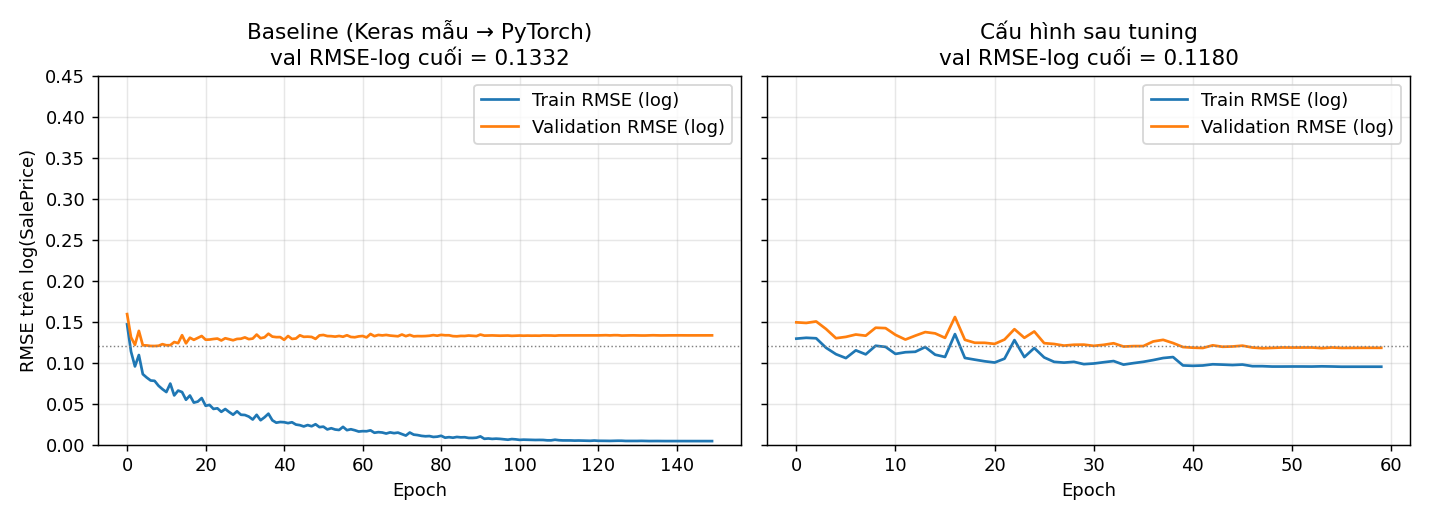

In [5]:
display(Image(f'{EXP_DIR}/figures/fig_learning_curve.png'))

## 5. Hyperparameter tuning (random search 25 cấu hình, 3-fold CV)

,id,hidden,dropout,weight_decay,lr,batch_size,epochs,optimizer,batchnorm,cv_rmse_log,cv_rmse
2,2,"(256, 128, 64)",0.0,0.0100,0.001,16,60,adam,False,0.1127,20722.7331
6,6,"(128, 64)",0.2,0.0010,0.001,64,100,adamax,False,0.1129,20977.1979
1,1,"(50, 25, 50)",0.0,0.0010,0.001,16,60,adamax,False,0.1153,21115.4362
9,9,"(128, 64)",0.3,0.0010,0.001,32,100,adam,True,0.1173,22020.7578
20,20,"(64, 32)",0.2,0.0001,0.010,64,60,adamax,True,0.1181,22366.3757
13,13,"(64, 32)",0.2,0.0001,0.001,64,150,adamax,True,0.1186,22356.1576
12,12,"(64, 32)",0.2,0.0001,0.010,32,100,adamax,True,0.1198,22413.6621
19,19,"(256, 128, 64)",0.1,0.0000,0.010,32,150,adamax,False,0.1201,22378.4505


Baseline (id=0): 0.132


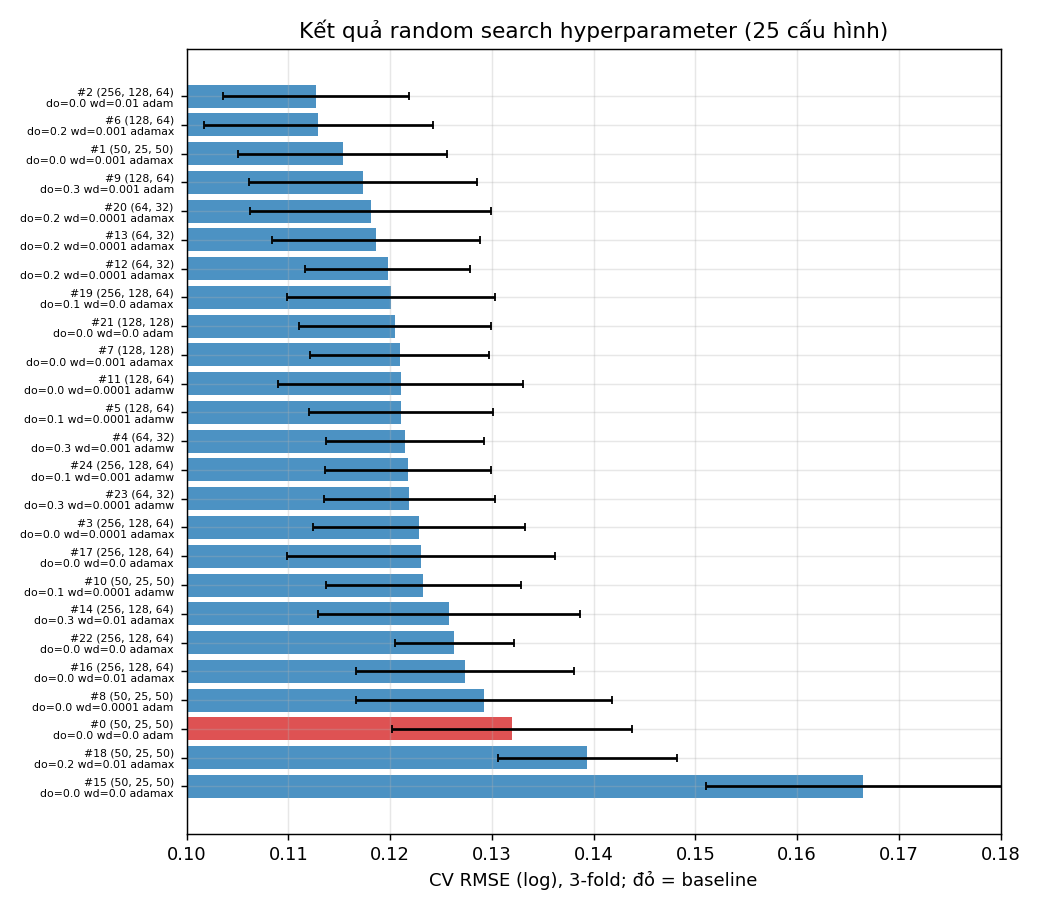

In [6]:
t=pd.read_csv(f'{EXP_DIR}/tuning_results.csv').sort_values('cv_rmse_log')
display(t[['id','hidden','dropout','weight_decay','lr','batch_size','epochs','optimizer','batchnorm','cv_rmse_log','cv_rmse']].head(8).round(4))
print('Baseline (id=0):', t[t.id==0].cv_rmse_log.round(4).item())
display(Image(f'{EXP_DIR}/figures/fig_tuning.png'))

### 5b. Ablation: đổi một hyperparameter so với cấu hình tốt nhất (3-fold CV)

In [7]:
display(pd.read_csv(f'{EXP_DIR}/ablation_results.csv').sort_values('cv_rmse_log').round(4))

,variant,cv_rmse_log,std,cv_rmse
8,"hidden=(50,25,50)",0.1126,0.0087,20739.5514
0,cấu hình tốt nhất,0.1127,0.0091,20722.7331
7,batch_size=32,0.1138,0.0109,20959.9382
9,optimizer=adamax,0.1142,0.0110,21119.6139
4,epochs=30,0.1146,0.0110,21154.6901
3,epochs=150,0.1159,0.0071,20914.2188
6,lr=3e-3,0.1168,0.0069,21182.8158
5,dropout=0.2,0.1169,0.0097,22045.8763
1,weight_decay=0,0.1174,0.0112,22064.8802
2,weight_decay=1e-3,0.1225,0.0088,22173.3451


### 5c. Learning curve theo feature set + loss history đã lưu

,experiment,epoch,train_loss_mse,val_loss_mse,train_rmse_log,val_rmse_log
59,EXP-00,60,0.0090,0.0139,0.0950,0.1180
119,EXP-01,60,0.0091,0.0138,0.0954,0.1177
179,EXP-02,60,0.0089,0.0138,0.0945,0.1173
239,EXP-03,60,0.0089,0.0137,0.0943,0.1170
299,EXP-04,60,0.0093,0.0139,0.0964,0.1178


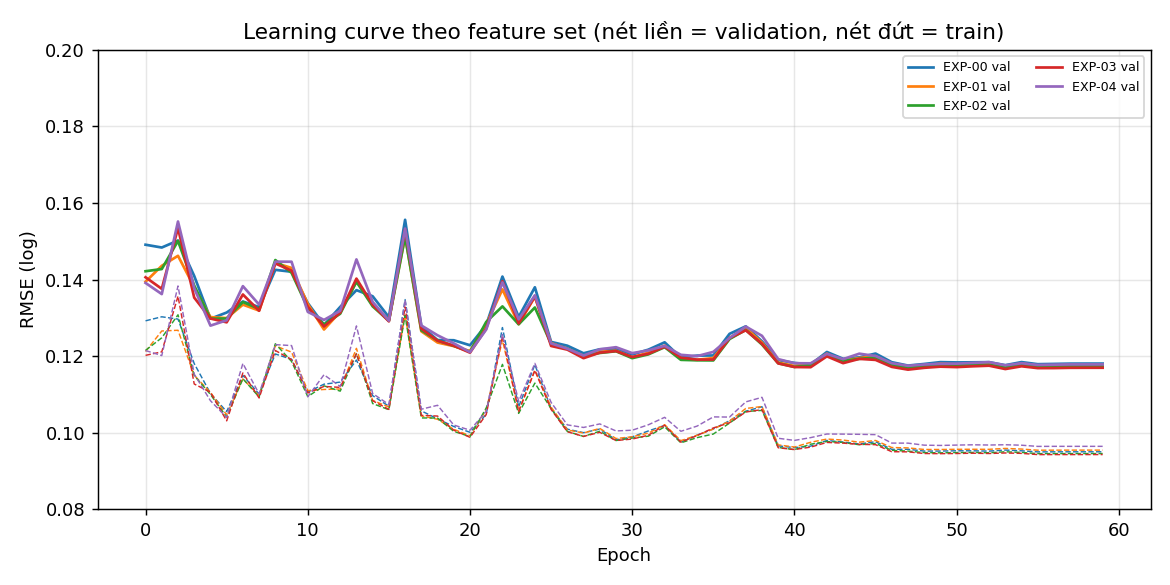

In [8]:
h=pd.read_csv(f'{EXP_DIR}/loss_history_featuresets.csv'); display(h.groupby('experiment').tail(1).round(4))
display(Image(f'{EXP_DIR}/figures/fig_learning_curve_featuresets.png'))

## 6. Các feature set EXP-00 → EXP-05 (5-fold CV)

,experiment,features,selection,config,n_features,cv_rmse_log,cv_rmse_log_std,cv_rmse,cv_mae,cv_bias,cv_max_dev
0,EXP-00,original,False,baseline,288,0.1342,0.0079,24784.6242,16655.9154,-677.0635,149134.1344
1,EXP-00,original,False,tuned,288,0.1124,0.0078,20404.7973,13372.2584,-1585.0486,133680.8094
2,EXP-01,area,False,baseline,289,0.1314,0.0105,24351.8793,16460.6242,-267.0152,138620.0844
3,EXP-01,area,False,tuned,289,0.1122,0.0077,20165.8254,13242.0020,-1534.8552,132733.7844
4,EXP-02,area+bath_porch,False,baseline,291,0.1385,0.0094,25021.3641,16979.1045,-1066.1372,142037.6719
5,EXP-02,area+bath_porch,False,tuned,291,0.1122,0.0076,20171.0402,13248.7635,-1510.0923,132487.9250
6,EXP-03,area+bath_porch+age,False,baseline,294,0.1334,0.0120,24478.9906,16653.1266,-870.9254,135860.8531
7,EXP-03,area+bath_porch+age,False,tuned,294,0.1119,0.0076,20113.7574,13175.6896,-1530.4206,131960.9656
8,EXP-04,area+bath_porch+age,True,baseline,204,0.1390,0.0054,24668.3512,16871.0137,-588.7397,134886.4656
9,EXP-04,area+bath_porch+age,True,tuned,204,0.1156,0.0047,20500.4492,13575.4316,-1514.8866,133794.6719


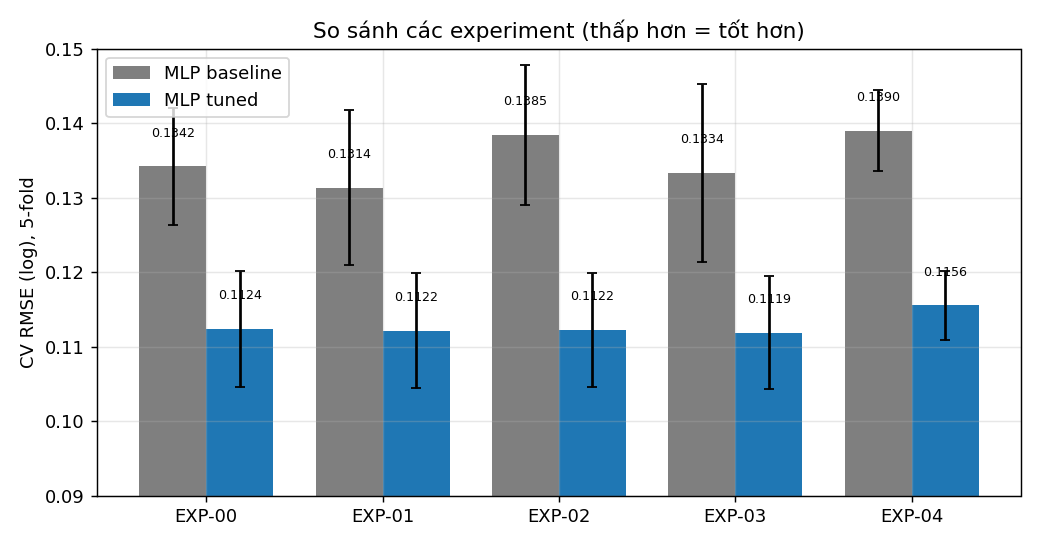

In [9]:
r=pd.read_csv(f'{EXP_DIR}/experiment_results.csv')
display(r[['experiment','features','selection','config','n_features','cv_rmse_log','cv_rmse_log_std','cv_rmse','cv_mae','cv_bias','cv_max_dev']].round(4))
display(Image(f'{EXP_DIR}/figures/fig_experiments.png'))

## 7. Chẩn đoán model cuối (holdout 80/20)

{'baseline': {'rmse_log': 0.1332198530435562, 'rmse': 22490.32421875, 'mae': 15956.623046875, 'bias': -3886.126708984375, 'max_dev': 112264.09375}, 'tuned': {'rmse_log': 0.11804886162281036, 'rmse': 19358.57421875, 'mae': 13338.197265625, 'bias': -2969.296142578125, 'max_dev': 102731.875}}


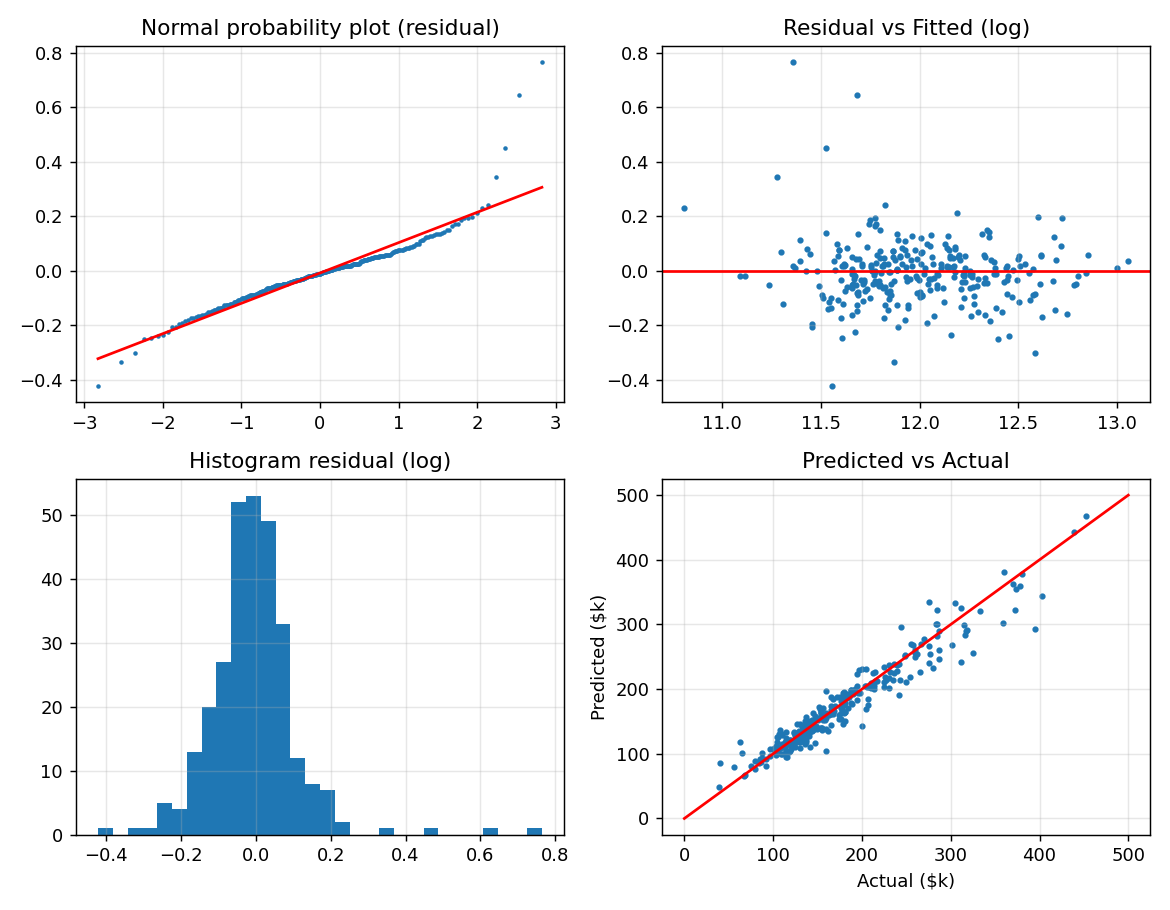

In [10]:
import json; print(json.load(open(f'{EXP_DIR}/holdout_metrics.json')))
display(Image(f'{EXP_DIR}/figures/fig_diagnostics.png'))

## 8. Model Check (theo Fig. 2 của paper)

In [11]:
sys.path.insert(0,'../src'); import model_check; model_check.main()

THỰC HIỆN KIỂM CHỨNG MODEL CHECK (Dean De Cock, 2011)

Quan sát kiểm tra: Id = 1
Giá bán thực tế (SalePrice): $208,500

--- 1. CÁC GIÁ TRỊ GỐC (RAW VALUES) ---
TotalBsmtSF: 856, 1stFlrSF: 856, 2ndFlrSF: 854
FullBath: 2, HalfBath: 1, BsmtFullBath: 1, BsmtHalfBath: 0
WoodDeckSF: 0, OpenPorchSF: 61, EnclosedPorch: 0, 3SsnPorch: 0, ScreenPorch: 0
YearBuilt: 2003, YearRemodAdd: 2003, GarageYrBlt: 2003.0, YrSold: 2008

--- 2. KẾT QUẢ ĐỐI SÁNH TÍNH TAY vs CODE PIPELINE ---
       Feature  Manual   Code  Match
       TotalSF  2566.0 2566.0   True
TotalBathrooms     3.5    3.5   True
  TotalPorchSF    61.0   61.0   True
      HouseAge     5.0    5.0   True
      RemodAge     5.0    5.0   True
     GarageAge     5.0    5.0   True

 KẾT LUẬN: Tất cả các đặc trưng phái sinh khớp 100% với tính toán giải tích!
Đã lưu kết quả Model Check tại: D:\UNIVERSITY\HocSau\SGU26K2_HocSau_S5_DCT123C4_0709_Nhom\Tuan03\lab03_house_prices\results\model_check_report.csv


,Feature,Manual,Code,Match
0,TotalSF,2566.0,2566.0,True
1,TotalBathrooms,3.5,3.5,True
2,TotalPorchSF,61.0,61.0,True
3,HouseAge,5.0,5.0,True
4,RemodAge,5.0,5.0,True
5,GarageAge,5.0,5.0,True


## 9. Submission

In [12]:
s=pd.read_csv('../submissions/submission_mlp.csv'); print(s.shape, s.columns.tolist(), s.SalePrice.isna().sum(), s.Id.equals(test.Id)); display(s.head())

(1459, 2) ['Id', 'SalePrice'] 0 True


,Id,SalePrice
0,1461,117428.960938
1,1462,158880.359375
2,1463,184580.593750
3,1464,198246.843750
4,1465,191674.656250
